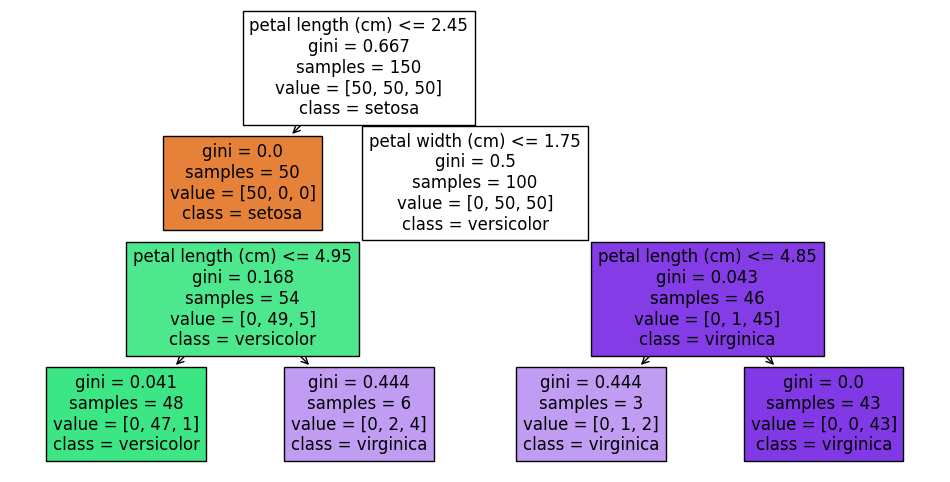

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

#change max depth
clf = DecisionTreeClassifier(max_depth=3
                             , random_state=42)
clf.fit(X, y)

plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()

In [2]:
import pandas as pd
import numpy as np

In [3]:
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
#print(iris['DESCR'])

In [5]:
df= pd.DataFrame(data= iris['data'],columns = iris['feature_names'])

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
df = df.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width'
})
df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
df['species'] =np.array(iris.target_names)[iris.target]
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

In [10]:
X = df.drop(['species'], axis =1)
y = df['species']

In [11]:
print('df shape',df.shape)
print('X shape', X.shape)
print('y shape', y.shape)

df shape (150, 5)
X shape (150, 4)
y shape (150,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
dt_pipe = Pipeline([
    ('clf',DecisionTreeClassifier(max_depth=3, random_state=42))
     ])

dt_pipe.fit(X_train,y_train)
dt_pred = dt_pipe.predict(X_test)
print('-- Decision Tree--')
print('accuracy', accuracy_score(y_test, dt_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, dt_pred))
print('\nClassifaction report\n', classification_report(y_test, dt_pred))

print('--DecisionTree Cross Val.--\n')

dt_cv=cross_val_score(dt_pipe, X,y,cv=5)
print(dt_cv)
print("Cross-Val Accuracy:\n", np.mean(dt_cv), "\n")


-- Decision Tree--
accuracy 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classifaction report
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--DecisionTree Cross Val.--

[0.96666667 0.96666667 0.93333333 1.         1.        ]
Cross-Val Accuracy:
 0.9733333333333334 

[0.         0.         0.93462632 0.06537368]


In [14]:
##GridSearch CV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__max_depth': [2, 3, 4, 5, None],
    'clf__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(dt_pipe, param_grid, cv=5)
grid.fit(X, y)

print('Best parameters:', grid.best_params_)
print('Best CV accuracy:', grid.best_score_)


Best parameters: {'clf__max_depth': 3, 'clf__min_samples_split': 2}
Best CV accuracy: 0.9733333333333334


In [15]:
#--- KNN Pipe---
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])
knn_pipe.fit(X_train, y_train)
knn_pred = knn_pipe.predict(X_test)

print('--KNN Classifier Pipe--')
print('Accuracy:', accuracy_score(y_test, knn_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, knn_pred))
print('Classification Report:\n', classification_report(y_test, knn_pred))

print('--KNN Classifier Cross Val.--\n')
knn_cv = cross_val_score(knn_pipe, X, y, cv=5)

print(knn_cv)
print('Cross-Val Accuracy:', np.mean(knn_cv))


--KNN Classifier Pipe--
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--KNN Classifier Cross Val.--

[0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Cross-Val Accuracy: 0.96


In [16]:
# --- Logistic Regression ---
from sklearn.linear_model import LogisticRegression
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=200, random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)

print('--Logistic Regression--')
print('Accuracy:', accuracy_score(y_test, lr_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, lr_pred))
print('Classification Report:\n', classification_report(y_test, lr_pred))

print('--Logistic Regression Cross Val.--\n')      
lr_cv = cross_val_score(lr_pipe, X, y, cv=5)
print('Cross-Val Accuracy:', np.mean(lr_cv), "\n")


--Logistic Regression--
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--Logistic Regression Cross Val.--

Cross-Val Accuracy: 0.9600000000000002 



- Decision Tree outperforms narrowly on CV — 0.9733 vs 0.96 for both KNN and Log Reg.
- Grid Search for KNN (n neighbors) and Logistic Regression (C value)hyperparameter tuning were not done
- Feature importances from the DT — ```dt_pipe.named_steps['clf'].feature_importances_```

In [18]:
feature_names = iris.feature_names
importances = dt_pipe.named_steps['clf'].feature_importances_

feat_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

print(feat_importance_df)


             Feature  Importance
0  sepal length (cm)    0.000000
1   sepal width (cm)    0.000000
2  petal length (cm)    0.934626
3   petal width (cm)    0.065374
